In [2]:
import re
import glob
from collections import defaultdict

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

plt.style.use("matlab.mplstyle")

In [90]:
FILENAME_SHARED_RE = re.compile(r"^(.+?)_shared_samples=(\d+)\.log$")
FILENAME_FULL_RE = re.compile(r"^(.+?)_full_samples=(\d+)\.log$")
FILENAME_SHARED_FULL_RE = re.compile(r"^(.+?)_shared_full_samples=(\d+)\.log$")
FILENAME_RE = re.compile(r"^(.+?)_samples=(\d+)\.log$")
LOG_LINE_RE = re.compile(r"\(test\)\s+algo\s+\S+\s*:\s*\{.*?'score'\s*:\s*([\d.]+)")


def parse_log_file(path):
    scores = []
    with open(path, "r", errors="replace") as f:
        for line in f:
            m = LOG_LINE_RE.search(line)
            if m:
                scores.append(float(m.group(1)))
    return scores


def collect_results(log_dir):
    shared = defaultdict(dict)
    full = defaultdict(dict)
    shared_full = defaultdict(dict)
    regular = defaultdict(dict)

    for fpath in sorted(glob.glob(f"{log_dir}/*.log")):
        fname = fpath.split("/")[-1]

        m = FILENAME_SHARED_FULL_RE.match(fname)
        if m:
            algo = m.group(1)
            n_samples = int(m.group(2))
            scores = parse_log_file(fpath)
            if scores:
                shared_full[algo][n_samples] = scores
            continue

        m = FILENAME_SHARED_RE.match(fname)
        if m:
            algo = m.group(1)
            n_samples = int(m.group(2))
            scores = parse_log_file(fpath)
            if scores:
                shared[algo][n_samples] = scores
            continue

        m = FILENAME_FULL_RE.match(fname)
        if m:
            algo = m.group(1)
            n_samples = int(m.group(2))
            scores = parse_log_file(fpath)
            if scores:
                full[algo][n_samples] = scores
            continue

        m = FILENAME_RE.match(fname)
        if m:
            algo = m.group(1)
            n_samples = int(m.group(2))
            scores = parse_log_file(fpath)
            if scores:
                regular[algo][n_samples] = scores

    return shared, full, shared_full, regular


def plot_series(ax, data, color, label, linestyle="-"):
    keys = sorted(data.keys())
    xs = [x * 5 for x in keys]
    means = [np.mean(data[x]) for x in keys]
    stds = [np.std(data[x]) for x in keys]

    ax.plot(xs, means, marker="o", color=color, linewidth=4, markersize=10, label=label, linestyle=linestyle)
    ax.fill_between(xs,
                    [m - s for m, s in zip(means, stds)],
                    [m + s for m, s in zip(means, stds)],
                    color=color, alpha=0.2)


def plot_results(shared, full, shared_full, regular, output_path):
    algorithms = sorted(set(shared.keys()) | set(full.keys()) | set(shared_full.keys()) | set(regular.keys()))
    n = len(algorithms)
    ncols = 4
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 7, nrows * 5))
    axes = axes.flatten()

    for i, algo in enumerate(algorithms):
        ax = axes[i]

        if algo in shared:
            plot_series(ax, shared[algo], "steelblue", "train + LoRA", linestyle="--")
        if algo in shared_full:
            plot_series(ax, shared_full[algo], "darkorange", "train + full")
        if algo in full:
            plot_series(ax, full[algo], "seagreen", "full")
        if algo in regular:
            plot_series(ax, regular[algo], "tomato", "LoRA", linestyle="--")

        ax.set_title(algo.replace("_", " "), fontsize=20)
        ax.set_ylim(0, 1.05)
        ax.set_xlabel("samples", fontsize=18)
        if i == 0:
            ax.set_ylabel("micro-F1", fontsize=18)
        ax.grid(True, alpha=0.3)
        ax.tick_params(labelsize=16)
        if i == 1:
            ax.legend(fontsize=18)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()

/tmp/ipykernel_106322/3264031472.py:84: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 7, nrows * 5))
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


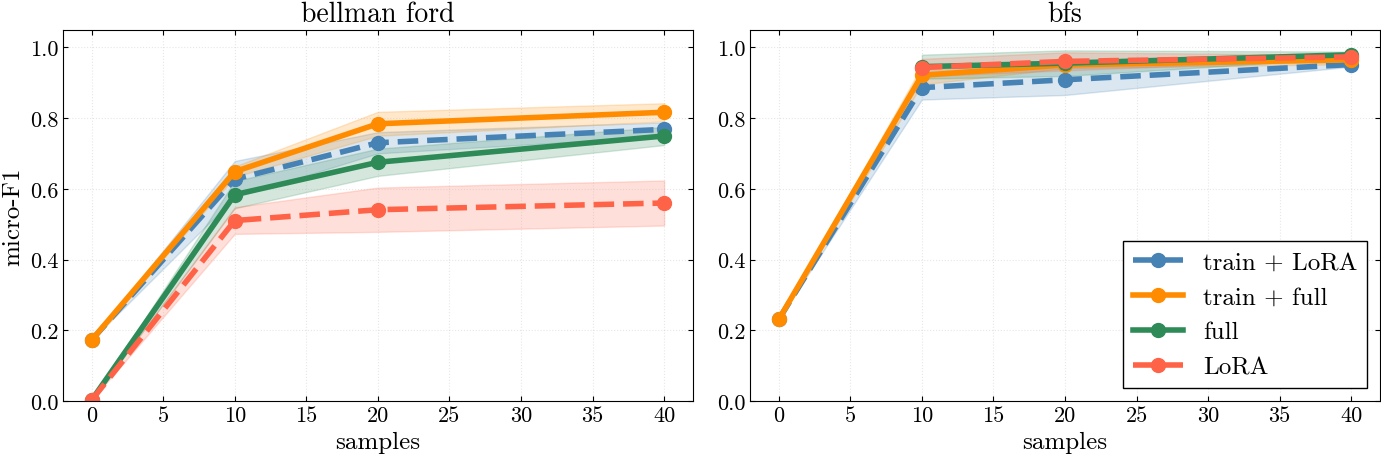

In [92]:
shared, full, shared_full, regular = collect_results("logs/lora")
plot_results(shared, full, shared_full, regular, "logs/gen_plot.pdf")

/tmp/ipykernel_106322/4269003311.py:27: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ax = plt.subplots(figsize=(17, 8))
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


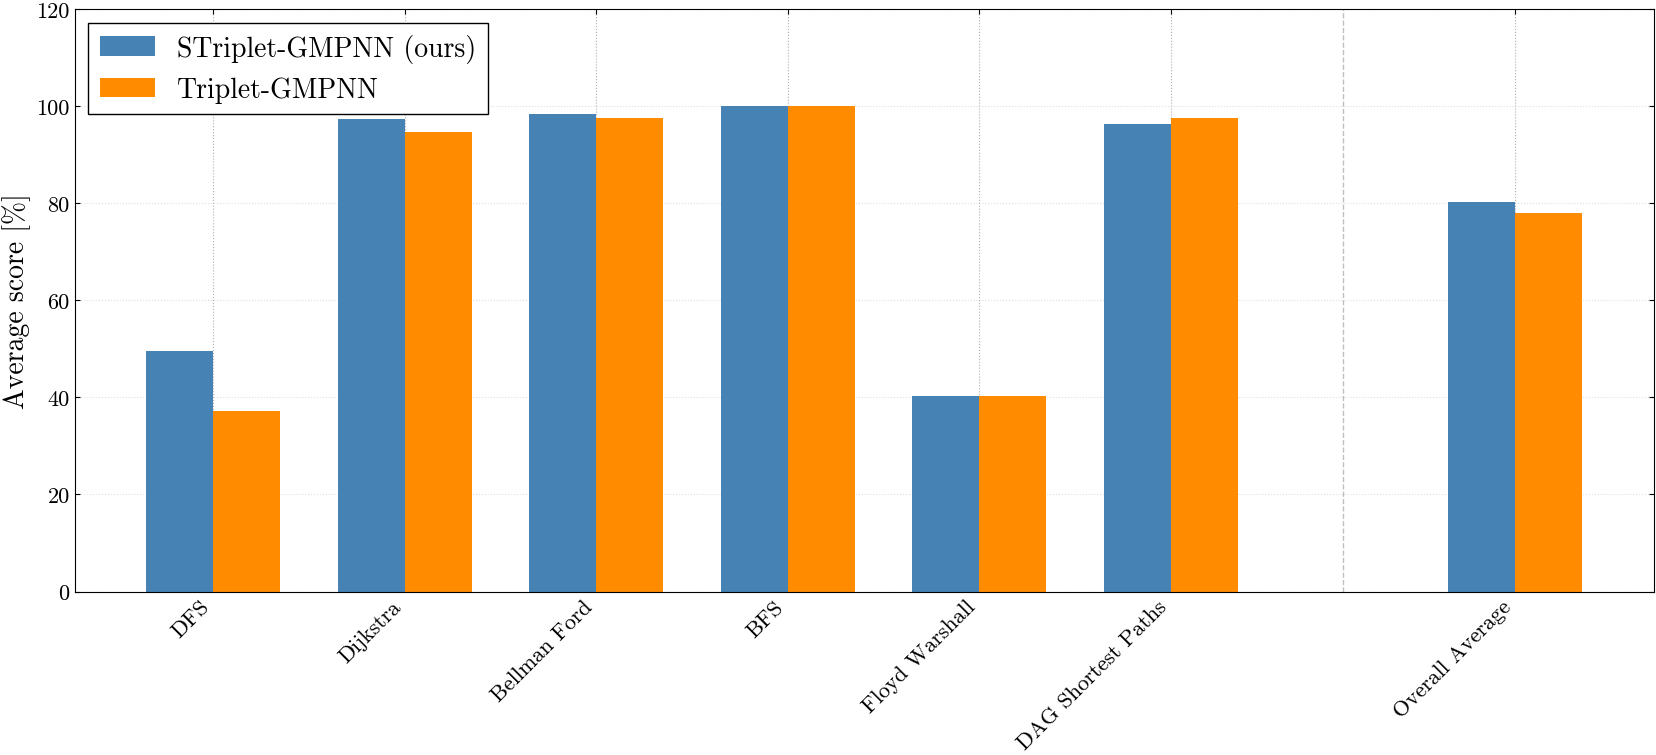

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

algorithms = ["BFS", "Bellman Ford", "DAG Shortest Paths", "Dijkstra", "Floyd Warshall", "DFS"]

triplet  = [100.00, 97.55, 97.46, 94.62, 40.31, 37.25]
striplet = [100.00, 98.29, 96.24, 97.36, 40.19, 49.56]

overall_triplet  = 77.86
overall_striplet = 80.27

# sort by striplet score descending
improvement = [s - t for s, t in zip(striplet, triplet)]
order = np.argsort(improvement)[::-1]
algorithms = [algorithms[i] for i in order]
triplet    = [triplet[i]  for i in order]
striplet   = [striplet[i] for i in order]

# add a gap then the overall bar
gap = 0.8
n = len(algorithms)
x = np.arange(n, dtype=float)
x_overall = x[-1] + 1 + gap

width = 0.35

fig, ax = plt.subplots(figsize=(17, 8))

ax.bar(x - width/2,        striplet,         width, label="STriplet-GMPNN (ours)", color="steelblue")
ax.bar(x + width/2,        triplet,          width, label="Triplet-GMPNN",         color="darkorange")
ax.bar(x_overall - width/2, overall_striplet, width, color="steelblue")
ax.bar(x_overall + width/2, overall_triplet,  width, color="darkorange")

all_x = list(x) + [x_overall]
all_labels = algorithms + ["Overall Average"]
ax.set_xticks(all_x)
ax.set_xticklabels(all_labels, rotation=45, ha="right", fontsize=16)

# draw a subtle vertical separator before the overall bar
sep_x = (x[-1] + x_overall) / 2
ax.axvline(sep_x, color="gray", linewidth=1, linestyle="--", alpha=0.5)

ax.set_ylabel("micro-F1 score [%]", fontsize=20)
ax.set_ylim(0, 120)
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)
ax.legend(fontsize=20)

plt.tight_layout()
plt.savefig("bar_plot.pdf", dpi=150, bbox_inches="tight")
plt.show()